In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
TRAIN_DIR = PROJECT_ROOT / "dataset" / "train"
TEST_DIR = PROJECT_ROOT / "dataset" / "test"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

print("Project folder:", PROJECT_ROOT)
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())
print("Model folder exists:", MODEL_DIR.exists())

Project folder: c:\Users\ASUS\OneDrive\Desktop\DeepFER
Train folder exists: True
Test folder exists: True
Model folder exists: True


In [ ]:
from pathlib import Path

emotion_classes = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("=" * 50)
print("TRAIN DATASET")
print("=" * 50)

total_train = 0

for emotion in emotion_classes:
    count = len(list((TRAIN_DIR / emotion).glob("*")))
    total_train += count
    print(f"{emotion:<10} : {count}")

print("-" * 50)
print("Total Training Images:", total_train)


print("\n" + "=" * 50)
print("TEST DATASET")
print("=" * 50)

total_test = 0

for emotion in emotion_classes:
    count = len(list((TEST_DIR / emotion).glob("*")))
    total_test += count
    print(f"{emotion:<10} : {count}")

print("-" * 50)
print("Total Testing Images:", total_test)

TRAIN DATASET
angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171
--------------------------------------------------
Total Training Images: 28709

TEST DATASET
angry      : 958
disgust    : 111
fear       : 1024
happy      : 1774
neutral    : 1233
sad        : 1247
surprise   : 831
--------------------------------------------------
Total Testing Images: 7178


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


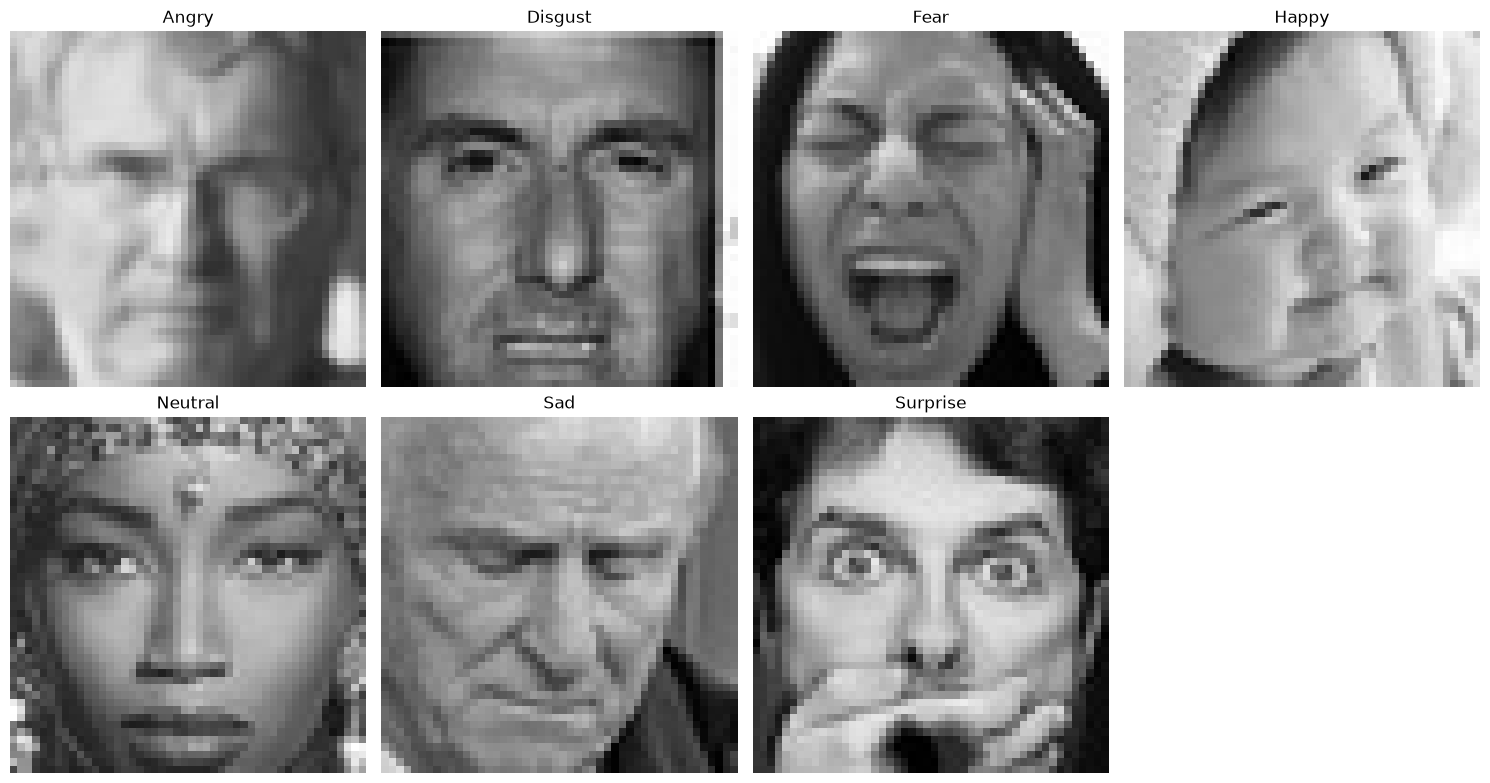

In [27]:
emotion_classes = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

plt.figure(figsize=(15, 8))

for i, emotion in enumerate(emotion_classes):

    folder = TRAIN_DIR / emotion

    image_path = random.choice(list(folder.glob("*")))

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(emotion.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (48, 48)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [29]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [30]:
print("Class labels:", train_generator.class_indices)

print("Training batches:", len(train_generator))
print("Validation batches:", len(validation_generator))
print("Testing batches:", len(test_generator))

Class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training batches: 718
Validation batches: 180
Testing batches: 225


In [31]:
NUM_CLASSES = len(train_generator.class_indices)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(48,48,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.30),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.40),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

model.summary()

c:\Users\ASUS\OneDrive\Desktop\DeepFER\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,743 (1.36 MB)

 Trainable params: 356,295 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [32]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("CNN compiled successfully.")

CNN compiled successfully.


In [33]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

MODEL_PATH = MODEL_DIR / "deepfer_model.keras"

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

]

print(MODEL_PATH)

c:\Users\ASUS\OneDrive\Desktop\DeepFER\models\deepfer_model.keras


In [35]:
EPOCHS = 20

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=callbacks
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2362 - loss: 1.8744
Epoch 1: val_accuracy improved from None to 0.24891, saving model to c:\Users\ASUS\OneDrive\Desktop\DeepFER\models\deepfer_model.keras

Epoch 1: finished saving model to c:\Users\ASUS\OneDrive\Desktop\DeepFER\models\deepfer_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 62s 83ms/step - accuracy: 0.2362 - loss: 1.8744 - val_accuracy: 0.2489 - val_loss: 1.7874 - learning_rate: 0.0010
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2753 - loss: 1.7587
Epoch 2: val_accuracy improved from 0.24891 to 0.31684, saving model to c:\Users\ASUS\OneDrive\Desktop\DeepFER\models\deepfer_model.keras

Epoch 2: finished saving model to c:\Users\ASUS\OneDrive\Desktop\DeepFER\models\deepfer_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.2753 - loss: 1.7587 - val_accuracy: 0.3168 - val_loss: 1.6672 - learning_rate: 0.0010
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 

In [36]:
best_model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5414 - loss: 1.1969
Test Loss: 1.1969
Test Accuracy: 0.5414


In [37]:
import numpy as np

test_generator.reset()

predictions = best_model.predict(
    test_generator,
    verbose=0
)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.40      0.47      0.43       958
     disgust       0.00      0.00      0.00       111
        fear       0.37      0.14      0.21      1024
       happy       0.81      0.77      0.79      1774
     neutral       0.46      0.59      0.52      1233
         sad       0.40      0.47      0.43      1247
    surprise       0.65      0.72      0.68       831

    accuracy                           0.54      7178
   macro avg       0.44      0.45      0.44      7178
weighted avg       0.53      0.54      0.53      7178



c:\Users\ASUS\OneDrive\Desktop\DeepFER\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\OneDrive\Desktop\DeepFER\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\OneDrive\Desktop\DeepFER\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

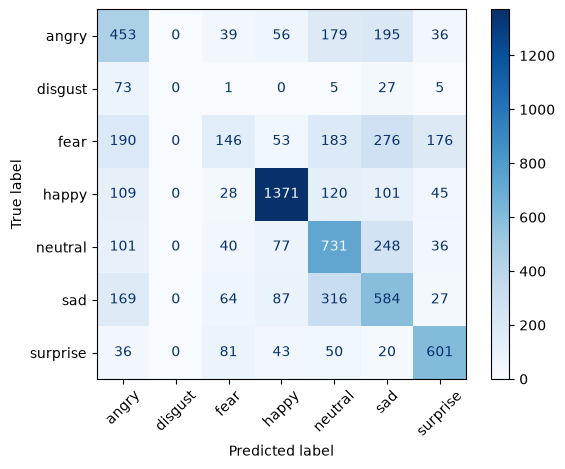

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=45
)

plt.show()

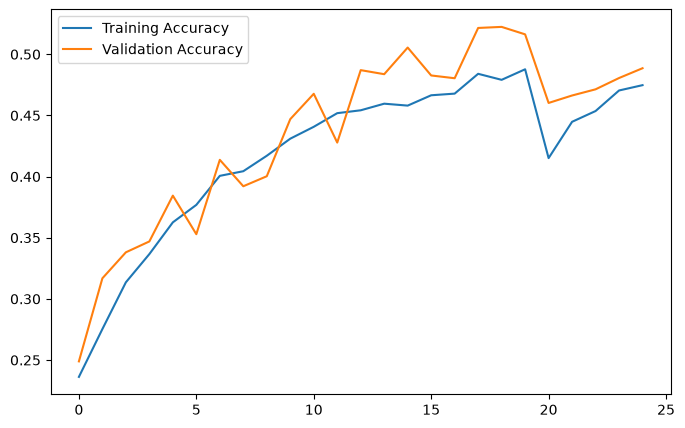

In [40]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

plt.figure(figsize=(8,5))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.show()

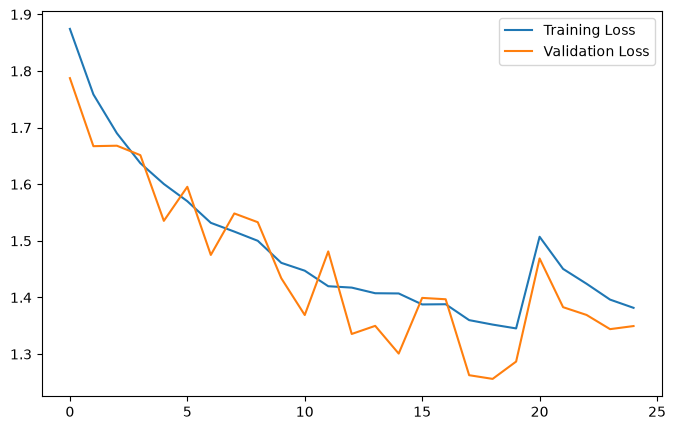

In [41]:
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(8,5))
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.show()